<div class="report-cover">
<img src="../assets/monash-university-logo.svg" class="monash-logo" alt="Monash University">
<div class="course">FIT5196 — Data Wrangling</div>
<h1>Assessment 1: Exploratory Data Analysis</h1>
<div class="group">Group030</div>
<p>King Man Chan · Yinglin Fang · Sizhe Hong · Xinhang Ren · Guohou Zhang</p>
</div>

<style>
.report-cover {min-height:720px; display:flex; flex-direction:column; justify-content:center; align-items:center; text-align:center; font-family:'Times New Roman', Times, serif;}
.monash-logo {width:280px; max-height:105px; object-fit:contain; margin-bottom:90px;}
.report-cover .course {font-size:18px; color:#111;}
.report-cover h1 {font-size:32px; color:#111; font-weight:normal; margin:18px 0 10px;}
.report-cover .group {font-size:22px; color:#111; margin:8px;}
@media print {
  .report-cover {page-break-after:always;}
  h2 {page-break-before:always; break-before:page;}
  h3, h4 {page-break-after:avoid; break-after:avoid-page;}
  img, table, .output_area, .jp-OutputArea {page-break-inside:avoid; break-inside:avoid-page;}
  pre {white-space:pre-wrap; overflow-wrap:anywhere;}
}
</style>

This notebook explores the six standardised tables created in our solution workflow. We start by checking the table grains and joins, then build seven assessed figures from the patterns that are actually present in the Group030 data. Each section keeps the preparation, calculation and plot in separate cells so the result can be followed from the submitted CSV files.

## Notebook map

1. Load and check the six tables  
2. Define the plot style and small statistical helpers  
3. Build Figures 1–7 one at a time  
4. Present ten evidence-based findings  
5. Frame five future machine-learning questions  
6. Discuss limitations and conclude  

The notebook is the reproducible source for the assessed figures and reported statistics. The PDF uses the same analysis but is typeset separately so code and long diagnostic outputs do not interrupt the report.

## Data-preparation assurance

The EDA begins with the six submitted relational tables rather than repeating the raw JSON/XML workflow. Four decisions from the solution are especially important here: source records were reconciled by normalised primary key before one canonical row was retained; item revenue and order totals were derived from reconciled values; narrative text was cleaned while the multilingual version and a separate Latin-analysis field were retained; and missing strings follow the required literal `NaN` contract. Examples are recorded in `MAP-orders-10`, `MAP-orders-15`, `MAP-orders-22` and the corresponding review mappings.

The validation register provides the main assurance for analysis. All six primary keys are complete and unique (`VAL-PK-01`–`VAL-PK-06`), all eight submitted foreign-key relationships have zero orphan keys (`VAL-FK-01`–`VAL-FK-08`), and normalised cross-source overlaps contain no conflicting non-missing values (`VAL-CONFLICT-01`). Order-item revenue and order arithmetic reconcile with a maximum difference of $0.00 (`VAL-ARITH-00`–`VAL-ARITH-02`). Delivery dates, delay fields and OTIF agree (`VAL-TIME-01`–`VAL-TIME-03B`), while the 303 reviews containing non-Latin script remain identified after cleaning (`VAL-TEXT-02`). These checks do not prove that every source value is correct, but they reduce the main risks of duplicate counting, broken joins and inconsistent derived measures.

## 0. Configuration

The same notebook can run inside this repository or from the flat submission folder. In the repository it reads `processing/outputs` and saves figures in `processing/figures`; in the submission layout it uses `outputs` and `figures` beside the notebook.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, PercentFormatter

GROUP_ID = 'Group030'
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / 'processing' / 'outputs').is_dir():
    OUTPUT_DIR = PROJECT_ROOT / 'processing' / 'outputs'
    FIGURE_DIR = PROJECT_ROOT / 'processing' / 'figures'
else:
    OUTPUT_DIR = PROJECT_ROOT / 'outputs'
    FIGURE_DIR = PROJECT_ROOT / 'figures'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_NAMES = ['orders', 'order_items', 'customers', 'deliveries', 'products', 'product_reviews']

### 0.1 Use one visual style throughout

We use a restrained blue–orange palette, light horizontal grids and direct units. Colours keep the same meaning where possible: blue for the main estimate, orange for a comparison, and grey for reference values.

In [2]:
BLUE = '#2F6690'
LIGHT_BLUE = '#8CB9D9'
ORANGE = '#D97732'
GREEN = '#4C956C'
PURPLE = '#7A6FA8'
DARK = '#243746'
GREY = '#7B8794'
PALE = '#E9EFF4'

plt.rcParams.update({
    'figure.figsize': (10, 5.8),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.edgecolor': '#C6D0D8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'legend.frameon': False,
    'font.family': 'DejaVu Sans',
})

aud = FuncFormatter(lambda value, _: f'${value/1000:,.0f}k' if abs(value) >= 1000 else f'${value:,.0f}')
aud_k1 = FuncFormatter(lambda value, _: f'${value/1000:,.1f}k')

## 1. Load the submitted tables

The EDA starts from the six CSV files. It does not rerun the JSON/XML cleaning workflow.

In [3]:
tables = {
    name: pd.read_csv(
        OUTPUT_DIR / f'{GROUP_ID}_{name}_standardised.csv',
        keep_default_na=False,
    )
    for name in TABLE_NAMES
}

table_sizes = pd.DataFrame([
    {'table': name, 'rows': len(frame), 'columns': len(frame.columns)}
    for name, frame in tables.items()
])
table_sizes

,table,rows,columns
0,orders,5000,23
1,order_items,15723,6
2,customers,500,20
3,deliveries,5000,20
4,products,1000,21
5,product_reviews,7000,21


### 1.1 Convert the fields used in this analysis

CSV files do not retain all pandas types. We convert only the numeric, date and boolean fields needed below and keep identifiers as strings.

In [4]:
orders = tables['orders'].copy()
order_items = tables['order_items'].copy()
customers = tables['customers'].copy()
deliveries = tables['deliveries'].copy()
products = tables['products'].copy()
reviews = tables['product_reviews'].copy()

for field in ['order_price', 'order_total', 'coupon_discount', 'delivery_charges']:
    orders[field] = pd.to_numeric(orders[field])
for field in ['quantity', 'unit_price', 'line_revenue']:
    order_items[field] = pd.to_numeric(order_items[field])
for field in ['unit_cost', 'unit_price']:
    products[field] = pd.to_numeric(products[field])
for field in ['rating', 'review_length_chars', 'helpful_votes']:
    reviews[field] = pd.to_numeric(reviews[field])
for field in ['fulfilment_hours', 'delay_days']:
    deliveries[field] = pd.to_numeric(deliveries[field])

orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])
reviews['review_timestamp'] = pd.to_datetime(reviews['review_timestamp'])
for field in ['dispatch_date', 'promised_date', 'delivered_date']:
    deliveries[field] = pd.to_datetime(deliveries[field])
deliveries['otif'] = deliveries['on_time_in_full'].astype(str).eq('True')

### 1.2 Recheck grains and keys before joining

The figures use order, item, customer, delivery and review grains. A join is accepted only when the parent key is unique and the number of rows on the left is unchanged.

In [5]:
key_checks = pd.DataFrame([
    {'table': 'orders', 'key': 'order_id', 'rows': len(orders), 'unique_keys': orders.order_id.nunique()},
    {'table': 'order_items', 'key': 'order_item_id', 'rows': len(order_items), 'unique_keys': order_items.order_item_id.nunique()},
    {'table': 'customers', 'key': 'customer_id', 'rows': len(customers), 'unique_keys': customers.customer_id.nunique()},
    {'table': 'deliveries', 'key': 'delivery_id', 'rows': len(deliveries), 'unique_keys': deliveries.delivery_id.nunique()},
    {'table': 'products', 'key': 'product_id', 'rows': len(products), 'unique_keys': products.product_id.nunique()},
    {'table': 'product_reviews', 'key': 'review_id', 'rows': len(reviews), 'unique_keys': reviews.review_id.nunique()},
])
key_checks['unique'] = key_checks.rows.eq(key_checks.unique_keys)
assert key_checks['unique'].all()
key_checks

,table,key,rows,unique_keys,unique
0,orders,order_id,5000,5000,True
1,order_items,order_item_id,15723,15723,True
2,customers,customer_id,500,500,True
3,deliveries,delivery_id,5000,5000,True
4,products,product_id,1000,1000,True
5,product_reviews,review_id,7000,7000,True


In [6]:
def checked_many_to_one(left, right, key, label):
    before = len(left)
    joined = left.merge(right, on=key, how='left', validate='many_to_one')
    after = len(joined)
    assert before == after, f'{label}: the join changed the left-table grain'
    assert joined[right.columns.difference([key])].notna().any(axis=1).all(), f'{label}: unmatched parent key'
    return joined, {'join': label, 'rows_before': before, 'rows_after': after}

## 2. Small statistical helpers

The figures report uncertainty where group estimates are compared. We use a standard mean confidence interval for continuous outcomes and a Wilson interval for an OTIF proportion. Wilson intervals avoid the unstable shape of a simple normal interval when a proportion is close to zero or one.

In [7]:
def mean_summary(frame, group, value):
    result = frame.groupby(group, observed=True)[value].agg(['count', 'mean', 'std']).reset_index()
    result['ci95'] = 1.96 * result['std'] / np.sqrt(result['count'])
    return result


def wilson_interval(successes, total, z=1.96):
    proportion = successes / total
    denominator = 1 + z**2 / total
    centre = (proportion + z**2 / (2 * total)) / denominator
    half = z * math.sqrt(proportion * (1 - proportion) / total + z**2 / (4 * total**2)) / denominator
    return centre - half, centre + half


def save_figure(fig, number):
    fig.savefig(FIGURE_DIR / f'Figure_{number}.png', dpi=200, bbox_inches='tight', facecolor='white')

## 3. Assessed visualisations

The seven questions below were selected after reviewing the table distributions. Together they cover a distribution, a group comparison, a segmented product analysis, time, customer behaviour, delivery operations and review behaviour. Figures 3, 5, 6 and 7 use related tables, with the joins checked before aggregation.

## Figure 1 — What does a typical order look like, and where does the high-value tail begin?

**Unit and denominator:** one order; all 5,000 canonical orders.  
**Table:** `orders`; no join.  
**Measure:** `order_total`, with the median and empirical 90th percentile.  

A histogram is appropriate here because order value is continuous and strongly right-skewed. We keep this figure close to the earlier version because it already showed the distribution and decision threshold clearly.

In [8]:
order_value_summary = orders.order_total.describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame('AUD')
order_value_summary

,AUD
count,5000.000000
mean,3000.371150
std,2104.542556
min,26.860000
25%,1423.200000
50%,2555.435000
75%,4048.040000
90%,5760.763000
max,15891.500000


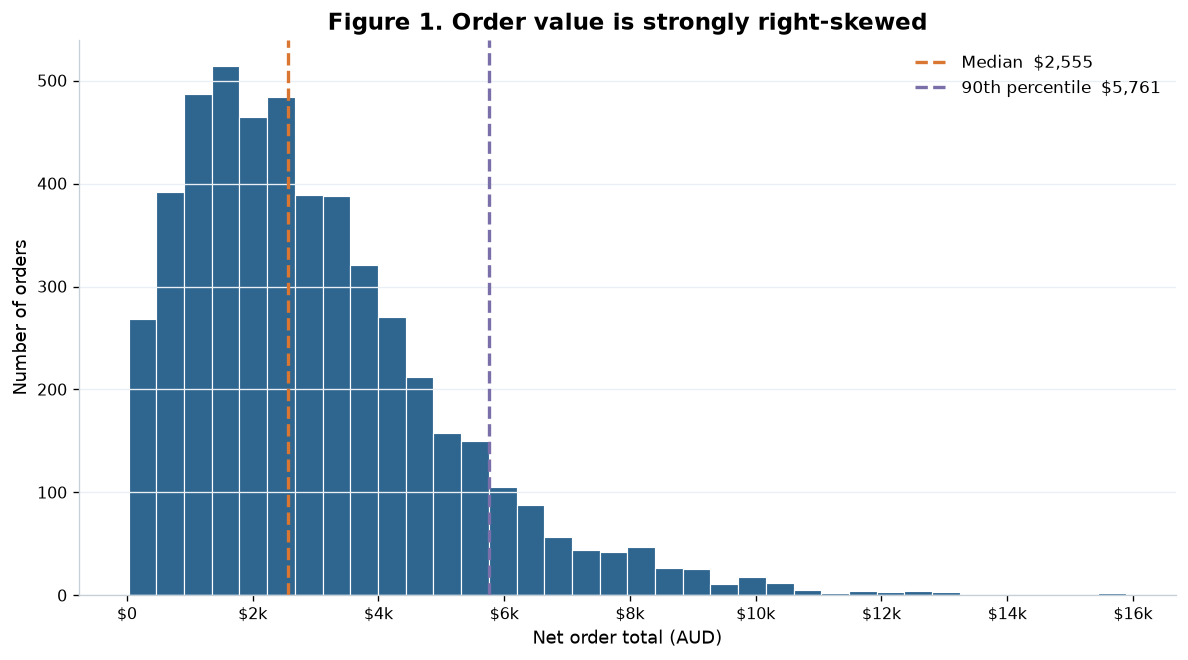

In [9]:
median_total = orders.order_total.median()
p90_total = orders.order_total.quantile(0.90)

fig1, ax = plt.subplots(figsize=(10, 5.6))
ax.hist(orders.order_total, bins=36, color=BLUE, edgecolor='white', linewidth=0.7)
ax.axvline(median_total, color=ORANGE, linestyle='--', linewidth=2, label=f'Median  ${median_total:,.0f}')
ax.axvline(p90_total, color=PURPLE, linestyle='--', linewidth=2, label=f'90th percentile  ${p90_total:,.0f}')
ax.set_title('Figure 1. Order value is strongly right-skewed')
ax.set_xlabel('Net order total (AUD)')
ax.set_ylabel('Number of orders')
ax.xaxis.set_major_formatter(aud)
ax.grid(axis='y', color=PALE, linewidth=0.8)
ax.legend(loc='upper right')
fig1.tight_layout()
save_figure(fig1, 1)
plt.show()

The median order is **$2,555.44**, while the highest 10% begin at **$5,760.76**. The long upper tail means that a mean alone would overstate a typical order. This is a value threshold rather than a profitability threshold because costs and discounts are not allocated at order level.

## Figure 2 — Are deeper discounts associated with larger gross baskets?

**Unit and denominator:** one order within each coupon-discount group; all 5,000 orders.  
**Table:** `orders`; no join.  
**Measure:** gross `order_price` before discount, shown by median, interquartile range and mean.  

We deliberately do not use `order_total` as the main outcome here. Its decline is partly built into the order-total formula, whereas gross basket value can show whether deeper coupons are associated with customers placing larger baskets.

In [10]:
discount_order = [0, 5, 10, 15, 20, 25]
discount_summary = orders.groupby('coupon_discount').order_price.agg(
    orders='size', mean='mean', median='median',
    q1=lambda values: values.quantile(0.25),
    q3=lambda values: values.quantile(0.75),
    std='std',
).reindex(discount_order)
discount_summary['mean_ci95'] = 1.96 * discount_summary['std'] / np.sqrt(discount_summary['orders'])
discount_summary.round(2)

,orders,mean,median,q1,q3,std,mean_ci95
coupon_discount,,,,,,,
0,1797,3194.58,2830.16,1506.41,4389.65,2177.64,100.69
5,1008,3249.81,2741.96,1616.97,4319.44,2220.11,137.06
10,959,3202.16,2731.51,1493.02,4322.20,2313.86,146.45
15,726,3195.56,2807.36,1429.38,4354.23,2342.65,170.41
20,354,3351.24,2780.20,1536.13,4381.60,2548.64,265.50
25,156,3358.61,3004.11,1613.46,4431.85,2220.45,348.44


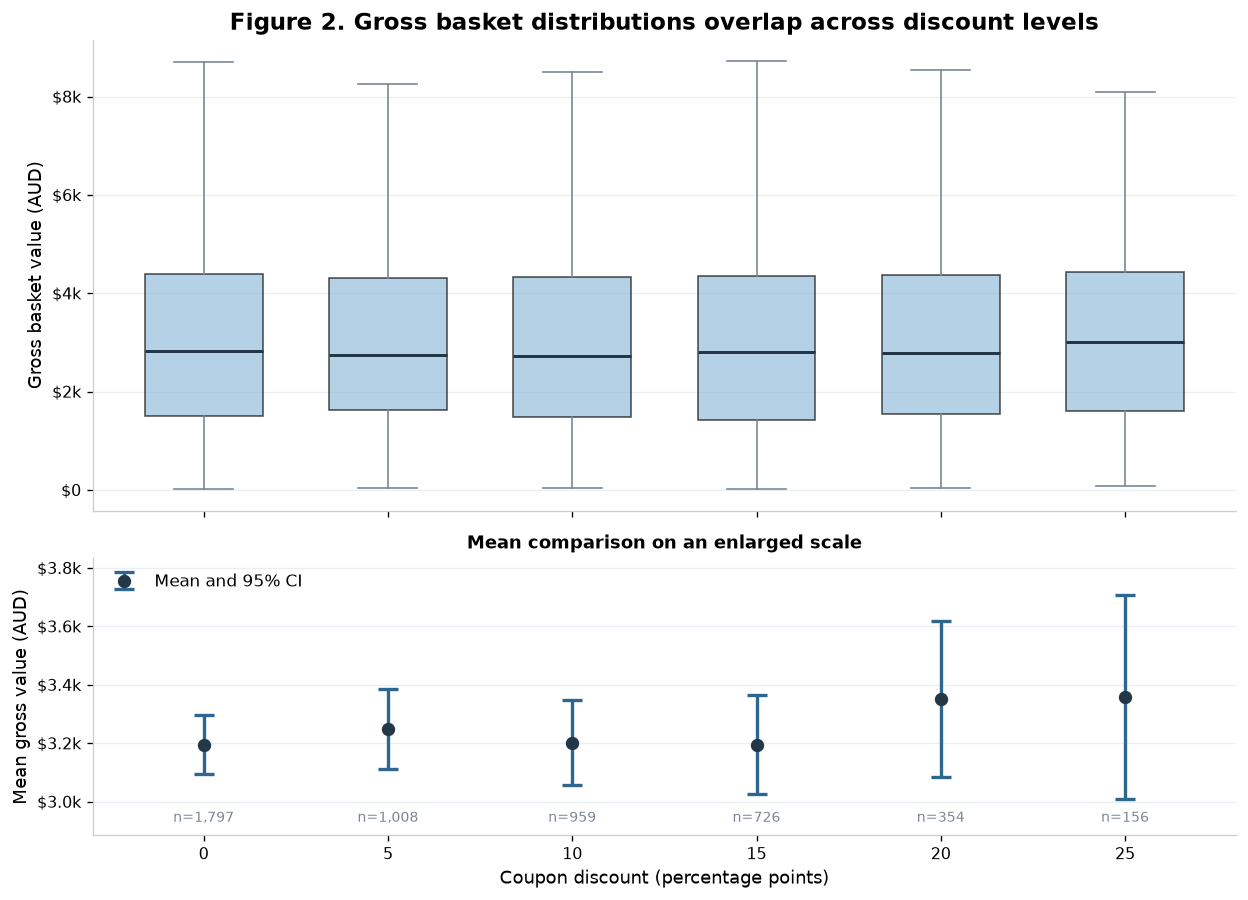

In [11]:
fig2, (ax_dist, ax_mean) = plt.subplots(2, 1, figsize=(10.5, 7.6), sharex=True,
                                           gridspec_kw={'height_ratios': [1.7, 1]})
box_data = [orders.loc[orders.coupon_discount.eq(level), 'order_price'] for level in discount_order]
box = ax_dist.boxplot(box_data, positions=discount_order, widths=3.2, patch_artist=True,
                 showfliers=False, medianprops={'color': DARK, 'linewidth': 1.8},
                 whiskerprops={'color': GREY}, capprops={'color': GREY})
for patch in box['boxes']:
    patch.set_facecolor(LIGHT_BLUE)
    patch.set_alpha(0.65)

ax_mean.errorbar(discount_order, discount_summary['mean'], yerr=discount_summary['mean_ci95'],
                 fmt='o', color=DARK, ecolor=BLUE, elinewidth=2, capsize=6,
                 capthick=2, markersize=7, label='Mean and 95% CI')
ci_low = (discount_summary['mean'] - discount_summary['mean_ci95']).min()
ci_high = (discount_summary['mean'] + discount_summary['mean_ci95']).max()
ci_pad = max(60, (ci_high - ci_low) * 0.18)
ax_mean.set_ylim(ci_low - ci_pad, ci_high + ci_pad)
for level, row in discount_summary.iterrows():
    ax_mean.text(level, ci_low - ci_pad * 0.72, f"n={int(row['orders']):,}",
                 ha='center', va='bottom', fontsize=8.5, color=GREY)

ax_dist.set_title('Figure 2. Gross basket distributions overlap across discount levels')
ax_dist.set_ylabel('Gross basket value (AUD)')
ax_dist.yaxis.set_major_formatter(aud)
ax_dist.grid(axis='y', color=PALE, linewidth=0.8)
ax_mean.set_title('Mean comparison on an enlarged scale', fontsize=11)
ax_mean.set_xlabel('Coupon discount (percentage points)')
ax_mean.set_ylabel('Mean gross value (AUD)')
ax_mean.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'${value / 1000:.1f}k'))
ax_mean.grid(axis='y', color=PALE, linewidth=0.8)
ax_mean.legend(loc='upper left')
fig2.tight_layout()
save_figure(fig2, 2)
plt.show()

Mean gross basket value ranges only from about **$3,195 to $3,359**, and the interquartile ranges overlap heavily. The 20% and 25% groups are much smaller, so their mean estimates are less precise. This is an observational comparison: coupon targeting and customer/product mix may differ between groups.

## Figure 3 — Which product categories combine economic scale with a strong estimated margin rate?

**Unit and denominator:** one canonical order-item line; all 15,723 lines.  
**Tables and join:** `order_items.product_id → products.product_id`, many-to-one.  
**Measures:** estimated margin contribution and estimated margin rate by category.  

Contribution and rate answer different questions. Showing them side by side prevents a large category from looking efficient only because it has more sales, or a small category from looking most important only because it has a high percentage.

In [12]:
item_product, figure3_join = checked_many_to_one(
    order_items,
    products[['product_id', 'category', 'unit_cost']],
    'product_id',
    'order items to products',
)
figure3_join

{'join': 'order items to products', 'rows_before': 15723, 'rows_after': 15723}

In [13]:
item_product['estimated_margin'] = (
    item_product['line_revenue'] - item_product['quantity'] * item_product['unit_cost']
)
category_summary = item_product.groupby('category').agg(
    lines=('order_item_id', 'size'),
    revenue=('line_revenue', 'sum'),
    estimated_margin=('estimated_margin', 'sum'),
).sort_values('estimated_margin')
category_summary['margin_rate'] = category_summary.estimated_margin / category_summary.revenue
category_summary.round(3)

,lines,revenue,estimated_margin,margin_rate
category,,,,
Accessory,2378,609356.55,224641.11,0.369
Smart Home,1953,925595.39,357746.24,0.387
Audio,1816,1162070.84,428969.59,0.369
Wearable,1738,1195512.30,458499.09,0.384
Networking,1519,1372194.80,547039.39,0.399
Tablet,1339,1458492.89,565860.33,0.388
Smartphone,1348,1805905.04,678950.05,0.376
Gaming,1396,2042078.10,783486.64,0.384
Laptop,1046,2670311.62,1003579.01,0.376


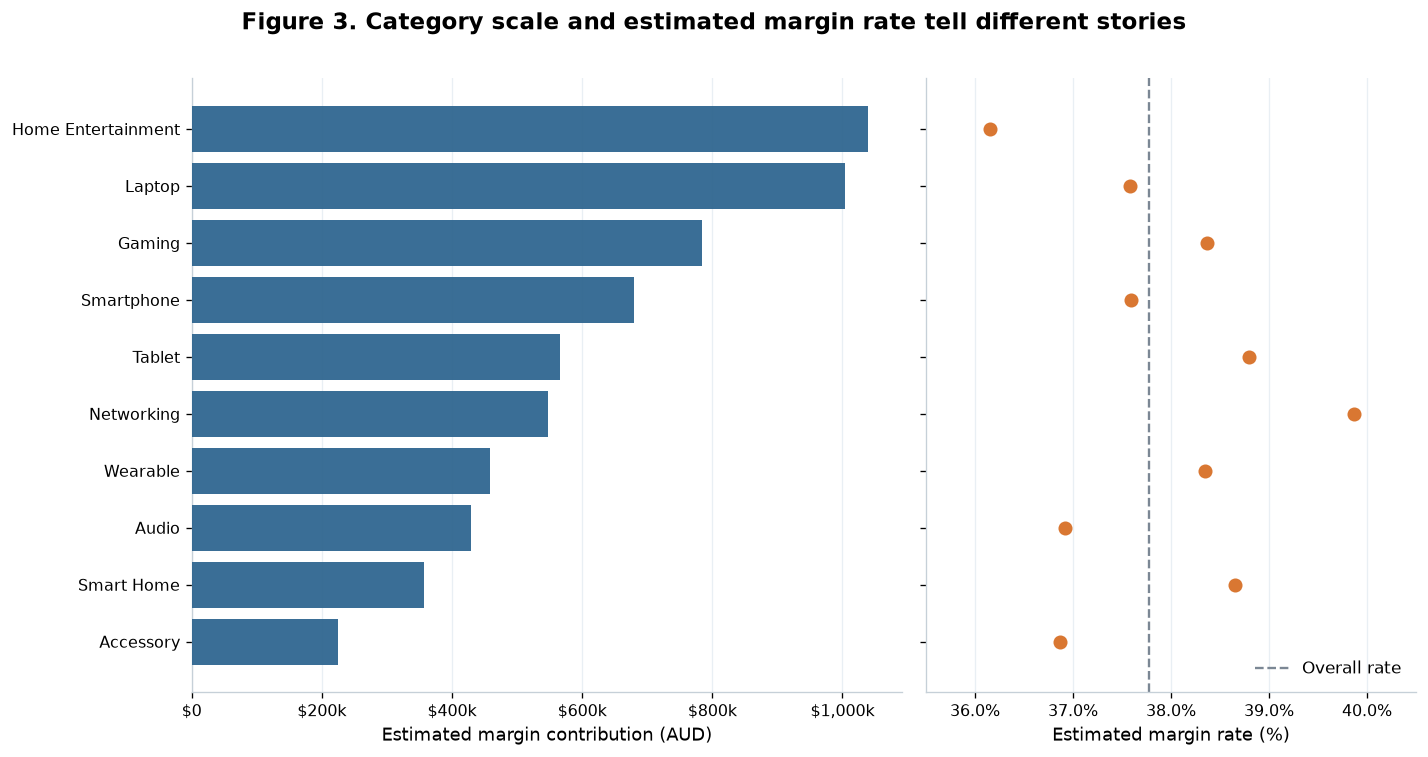

In [14]:
fig3, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6.2), sharey=True,
                                         gridspec_kw={'width_ratios': [1.45, 1]})
y = np.arange(len(category_summary))
ax_left.set_axisbelow(True)
ax_left.barh(y, category_summary.estimated_margin, color=BLUE, alpha=0.95, zorder=3)
ax_left.set_yticks(y, category_summary.index)
ax_left.set_xlabel('Estimated margin contribution (AUD)')
ax_left.xaxis.set_major_formatter(aud)
ax_left.grid(axis='x', color=PALE, linewidth=0.8)

ax_right.scatter(category_summary.margin_rate * 100, y, color=ORANGE, s=55, zorder=3)
ax_right.axvline(category_summary.estimated_margin.sum() / category_summary.revenue.sum() * 100,
                 color=GREY, linestyle='--', linewidth=1.4, label='Overall rate')
ax_right.set_xlabel('Estimated margin rate (%)')
ax_right.set_xlim(35.5, 40.5)
ax_right.xaxis.set_major_formatter(PercentFormatter(100, decimals=1))
ax_right.grid(axis='x', color=PALE, linewidth=0.8)
ax_right.legend(loc='lower right')

fig3.suptitle('Figure 3. Category scale and estimated margin rate tell different stories', y=1.01,
              fontsize=14, fontweight='bold')
fig3.tight_layout()
save_figure(fig3, 3)
plt.show()

Home Entertainment and Laptop contribute the largest estimated margin dollars, while Networking has the highest estimated rate. These values use catalogue unit cost and do not allocate coupon discounts, returns or overhead, so they should be described as an exploratory contribution measure rather than accounting profit.

## Figure 4 — Do monthly changes come from order frequency or order value?

**Unit and denominator:** calendar month, calculated from all orders in that month.  
**Table:** `orders`; no join.  
**Measures:** orders per calendar day and mean net order value.  

Months have different lengths, so raw monthly counts are not directly comparable. We divide each count by the number of calendar days before examining demand intensity.

In [15]:
orders['month'] = orders.order_timestamp.dt.to_period('M')
monthly = orders.groupby('month').agg(
    orders=('order_id', 'size'),
    mean_order_total=('order_total', 'mean'),
).reset_index()
monthly['calendar_days'] = monthly.month.dt.days_in_month
monthly['orders_per_day'] = monthly.orders / monthly.calendar_days
monthly['month_label'] = monthly.month.astype(str)
monthly[['month_label', 'orders', 'calendar_days', 'orders_per_day', 'mean_order_total']].round(2)

,month_label,orders,calendar_days,orders_per_day,mean_order_total
0,2018-01,438,31,14.13,2997.25
1,2018-02,364,28,13.00,3019.50
2,2018-03,417,31,13.45,2942.67
3,2018-04,436,30,14.53,3071.36
4,2018-05,415,31,13.39,2934.45
5,2018-06,428,30,14.27,3063.32
6,2018-07,414,31,13.35,3115.23
7,2018-08,423,31,13.65,3110.49
8,2018-09,419,30,13.97,2896.78
9,2018-10,409,31,13.19,2971.34


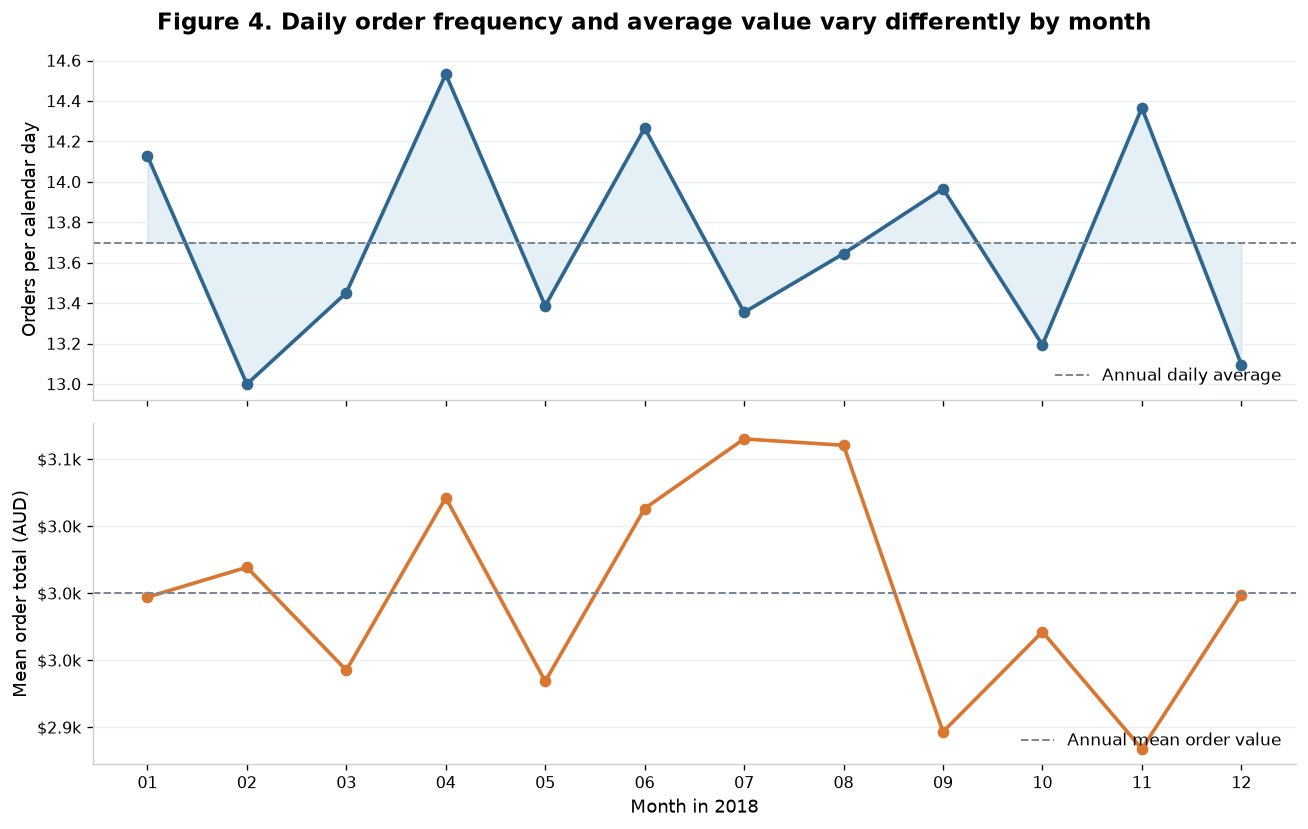

In [16]:
fig4, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
x = np.arange(len(monthly))
ax_top.plot(x, monthly.orders_per_day, color=BLUE, marker='o', linewidth=2.2)
ax_top.fill_between(x, monthly.orders_per_day, monthly.orders_per_day.mean(), color=LIGHT_BLUE, alpha=0.22)
ax_top.axhline(monthly.orders_per_day.mean(), color=GREY, linestyle='--', linewidth=1.2, label='Annual daily average')
ax_top.set_ylabel('Orders per calendar day')
ax_top.grid(axis='y', color=PALE, linewidth=0.8)
ax_top.legend(loc='lower right')

ax_bottom.plot(x, monthly.mean_order_total, color=ORANGE, marker='o', linewidth=2.2)
ax_bottom.axhline(orders.order_total.mean(), color=GREY, linestyle='--', linewidth=1.2, label='Annual mean order value')
ax_bottom.set_ylabel('Mean order total (AUD)')
ax_bottom.yaxis.set_major_formatter(aud_k1)
ax_bottom.set_xticks(x, monthly.month_label.str[-2:])
ax_bottom.set_xlabel('Month in 2018')
ax_bottom.grid(axis='y', color=PALE, linewidth=0.8)
ax_bottom.legend(loc='lower right')

fig4.suptitle('Figure 4. Daily order frequency and average value vary differently by month', y=0.98,
              fontsize=14, fontweight='bold')
fig4.tight_layout()
save_figure(fig4, 4)
plt.show()

Daily order frequency and average order value move differently rather than following one common trend. With only one calendar year and no campaign calendar, the pattern is useful for description but not enough to claim seasonality.

## Figure 5 — Does a customer’s prior order frequency carry into the current period?

**Unit and denominator:** one customer; all 500 customers.  
**Tables and join:** current orders are first aggregated to customer grain, then joined to `customers.customer_id` one-to-one.  
**Measures:** prior 12-month orders and current-period order count.  

Both variables are integer counts, so many customers occupy the same coordinate. A hexagonal count map shows this overlap more honestly than a plain scatter plot.

In [17]:
current_frequency = orders.groupby('customer_id').agg(
    current_orders=('order_id', 'size')
).reset_index()
customer_frequency = customers[['customer_id', 'prior_12m_orders']].merge(
    current_frequency, on='customer_id', how='left', validate='one_to_one'
)
customer_frequency['current_orders'] = customer_frequency.current_orders.fillna(0).astype(int)
customer_frequency['prior_12m_orders'] = pd.to_numeric(customer_frequency.prior_12m_orders)
assert len(customer_frequency) == len(customers)
frequency_correlation = customer_frequency.prior_12m_orders.corr(customer_frequency.current_orders)
customer_frequency.describe().round(2)

,prior_12m_orders,current_orders
count,500.00,500.00
mean,10.02,10.00
std,6.39,3.23
min,0.00,1.00
25%,4.00,8.00
50%,10.00,10.00
75%,15.00,12.00
max,21.00,23.00


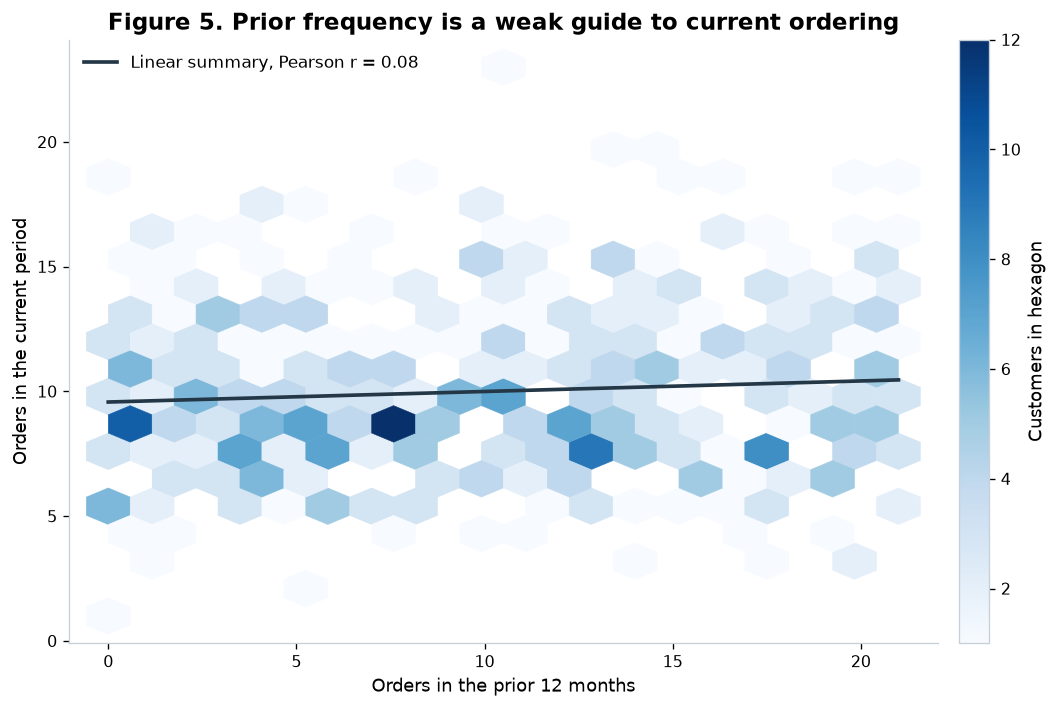

In [18]:
fig5, ax = plt.subplots(figsize=(9.5, 6))
hexes = ax.hexbin(customer_frequency.prior_12m_orders, customer_frequency.current_orders,
                  gridsize=18, mincnt=1, cmap='Blues', linewidths=0.3)
coef = np.polyfit(customer_frequency.prior_12m_orders, customer_frequency.current_orders, 1)
line_x = np.linspace(customer_frequency.prior_12m_orders.min(), customer_frequency.prior_12m_orders.max(), 100)
ax.plot(line_x, np.polyval(coef, line_x), color=DARK, linewidth=2.2,
        label=f'Linear summary, Pearson r = {frequency_correlation:.2f}')
colourbar = fig5.colorbar(hexes, ax=ax, pad=0.02)
colourbar.set_label('Customers in hexagon')
ax.set_title('Figure 5. Prior frequency is a weak guide to current ordering')
ax.set_xlabel('Orders in the prior 12 months')
ax.set_ylabel('Orders in the current period')
ax.legend(loc='upper left')
fig5.tight_layout()
save_figure(fig5, 5)
plt.show()

The correlation is only **0.08** across 500 customers. Historical frequency alone therefore provides little separation in this period. This does not mean customer history is useless: tenure, marketing exposure and product mix may explain changes that a two-variable plot cannot show.

## Figure 6 — Which carrier and service combinations differ in reliability or fulfilment time?

**Unit and denominator:** one completed delivery within each carrier–service group; all 5,000 deliveries.  
**Tables and join:** the submitted delivery table already carries carrier, service, OTIF and fulfilment fields; its `order_id` relationship to orders was checked in the solution workflow. No extra metric-producing join is required here.  
**Measures:** OTIF rate with Wilson 95% CI, and fulfilment-hours distribution.  

The two panels separate reliability from internal processing time. This avoids ranking a service on OTIF alone when its fulfilment-time distribution tells a different story.

In [19]:
operations = deliveries.groupby(['carrier', 'service_level']).agg(
    otif_successes=('otif', 'sum'),
    deliveries=('delivery_id', 'size'),
    otif_rate=('otif', 'mean'),
    median_fulfilment=('fulfilment_hours', 'median'),
).reset_index()
intervals = np.array([
    wilson_interval(successes, total)
    for successes, total in zip(operations.otif_successes, operations.deliveries)
])
operations['lower'] = intervals[:, 0]
operations['upper'] = intervals[:, 1]
operations['label'] = operations.carrier + ' — ' + operations.service_level
operations = operations.sort_values(['carrier', 'service_level']).reset_index(drop=True)
operations.round(4)

,carrier,service_level,otif_successes,deliveries,otif_rate,median_fulfilment,lower,upper,label
0,AusPost,Express,183,205,0.8927,42.0,0.8429,0.9281,AusPost — Express
1,AusPost,Standard,930,1050,0.8857,40.0,0.8650,0.9036,AusPost — Standard
2,DHL,Express,188,216,0.8704,36.5,0.8190,0.9088,DHL — Express
3,DHL,Standard,900,1029,0.8746,38.0,0.8530,0.8935,DHL — Standard
4,Direct Freight,Express,234,254,0.9213,38.0,0.8815,0.9485,Direct Freight — Express
5,Direct Freight,Standard,884,989,0.8938,38.0,0.8731,0.9115,Direct Freight — Standard
6,StarTrack,Express,230,253,0.9091,40.0,0.8673,0.9387,StarTrack — Express
7,StarTrack,Standard,915,1004,0.9114,38.0,0.8922,0.9274,StarTrack — Standard


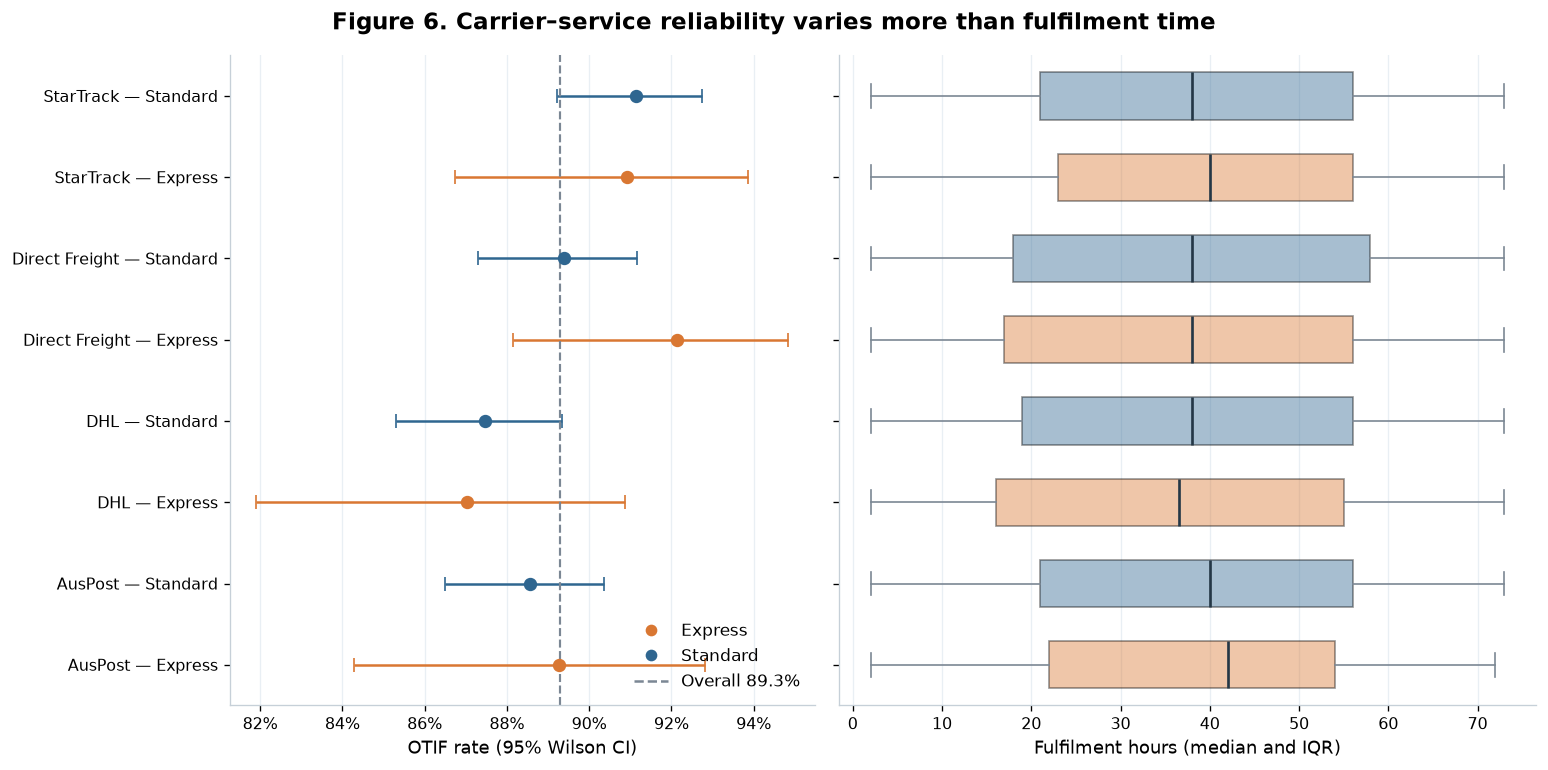

In [20]:
service_colours = {'Express': ORANGE, 'Standard': BLUE}
labels = operations.label.tolist()
y = np.arange(len(labels))

fig6, (ax_rate, ax_time) = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True,
                                        gridspec_kw={'width_ratios': [1.05, 1.25]})
for idx, row in operations.iterrows():
    colour = service_colours[row.service_level]
    ax_rate.errorbar(row.otif_rate * 100, idx,
                     xerr=[[100 * (row.otif_rate - row.lower)], [100 * (row.upper - row.otif_rate)]],
                     fmt='o', color=colour, capsize=4, markersize=7)
ax_rate.axvline(deliveries.otif.mean() * 100, color=GREY, linestyle='--', linewidth=1.3,
                label=f'Overall {deliveries.otif.mean():.1%}')
ax_rate.set_yticks(y, labels)
ax_rate.set_xlabel('OTIF rate (95% Wilson CI)')
ax_rate.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax_rate.grid(axis='x', color=PALE, linewidth=0.8)

fulfilment_groups = [
    deliveries.loc[
        deliveries.carrier.eq(row.carrier) & deliveries.service_level.eq(row.service_level),
        'fulfilment_hours'
    ]
    for _, row in operations.iterrows()
]
box = ax_time.boxplot(fulfilment_groups, orientation='horizontal', positions=y, widths=0.58,
                      showfliers=False, patch_artist=True,
                      medianprops={'color': DARK, 'linewidth': 1.6},
                      whiskerprops={'color': GREY}, capprops={'color': GREY})
for patch, service in zip(box['boxes'], operations.service_level):
    patch.set_facecolor(service_colours[service])
    patch.set_alpha(0.42)
ax_time.set_xlabel('Fulfilment hours (median and IQR)')
ax_time.grid(axis='x', color=PALE, linewidth=0.8)
ax_rate.set_yticks(y, labels)
ax_time.tick_params(axis='y', labelleft=False)
service_legend = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=ORANGE, markeredgecolor=ORANGE, label='Express'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=BLUE, markeredgecolor=BLUE, label='Standard'),
    Line2D([0], [0], color=GREY, linestyle='--', label=f'Overall {deliveries.otif.mean():.1%}'),
]
ax_rate.legend(handles=service_legend, loc='lower right')

fig6.suptitle('Figure 6. Carrier–service reliability varies more than fulfilment time', y=0.98,
              fontsize=14, fontweight='bold')
fig6.tight_layout()
save_figure(fig6, 6)
plt.show()

Overall OTIF is **89.3%**. The group estimates differ, but several intervals overlap, so the chart does not support a simple best-to-worst league table. Fulfilment-hour distributions also overlap substantially. Route mix, warehouse workload and destination distance remain plausible alternative explanations.

## Figure 7 — Are delivery timing and review delay associated with the rating left for an order?

**Unit and denominator:** one order with at least one review; 4,044 rated orders. Multiple reviews are averaged within order before joining.  
**Tables and join:** order-level `product_reviews.order_id → deliveries.order_id`, one-to-one after aggregation.  
**Measures:** mean order-level rating by early/on-date/late delivery and by days from delivery to first review, with 95% CIs on the full 1–5 scale.  

We distinguish early, on the promised date and late delivery instead of compressing them into a single OTIF flag. The second panel checks whether the timing of the review changes the descriptive pattern. This question was motivated by published e-commerce research on delivery timing and review timing, but all values below are calculated from Group030 data.

Reference: [Impact of delivery performance on online review ratings: the role of temporal distance of ratings](https://pmc.ncbi.nlm.nih.gov/articles/PMC9115748/).

In [21]:
order_rating = reviews.groupby('order_id').agg(
    order_mean_rating=('rating', 'mean'),
    review_count=('review_id', 'size'),
    first_review_timestamp=('review_timestamp', 'min'),
).reset_index()

rating_delivery = order_rating.merge(
    deliveries[['order_id', 'promised_date', 'delivered_date']],
    on='order_id', how='inner', validate='one_to_one'
)
assert len(rating_delivery) == len(order_rating)
rating_delivery['timing_days'] = (
    rating_delivery.delivered_date - rating_delivery.promised_date
).dt.days
rating_delivery['delivery_timing'] = np.select(
    [rating_delivery.timing_days.lt(0), rating_delivery.timing_days.eq(0)],
    ['Early', 'On promised date'],
    default='Late',
)
rating_delivery['review_lag_days'] = (
    rating_delivery.first_review_timestamp.dt.normalize() - rating_delivery.delivered_date
).dt.days

In [22]:
timing_order = ['Early', 'On promised date', 'Late']
timing_rating = mean_summary(rating_delivery, 'delivery_timing', 'order_mean_rating').set_index('delivery_timing').reindex(timing_order).reset_index()
rating_delivery['review_lag_band'] = pd.cut(
    rating_delivery.review_lag_days,
    bins=[0, 7, 14, 30, np.inf],
    labels=['1–7', '8–14', '15–30', '31–45'],
)
lag_rating = rating_delivery.groupby(['delivery_timing', 'review_lag_band'], observed=True).order_mean_rating.agg(
    count='size', mean='mean', std='std'
).reset_index()
lag_rating['ci95'] = 1.96 * lag_rating['std'] / np.sqrt(lag_rating['count'])
timing_rating.round(3), lag_rating.round(3)

(    delivery_timing  count   mean    std   ci95
 0             Early   2442  3.709  1.048  0.042
 1  On promised date   1166  3.717  1.012  0.058
 2              Late    436  3.752  1.006  0.094,
      delivery_timing review_lag_band  count   mean    std   ci95
 0              Early             1–7    606  3.762  0.947  0.075
 1              Early            8–14    523  3.661  0.941  0.081
 2              Early           15–30    835  3.710  1.092  0.074
 3              Early           31–45    478  3.693  1.193  0.107
 4               Late             1–7    108  3.819  0.902  0.170
 5               Late            8–14     99  3.884  0.890  0.175
 6               Late           15–30    138  3.603  1.089  0.182
 7               Late           31–45     91  3.756  1.093  0.225
 8   On promised date             1–7    289  3.764  0.891  0.103
 9   On promised date            8–14    242  3.669  0.963  0.121
 10  On promised date           15–30    409  3.671  1.049  0.102
 11  On pro

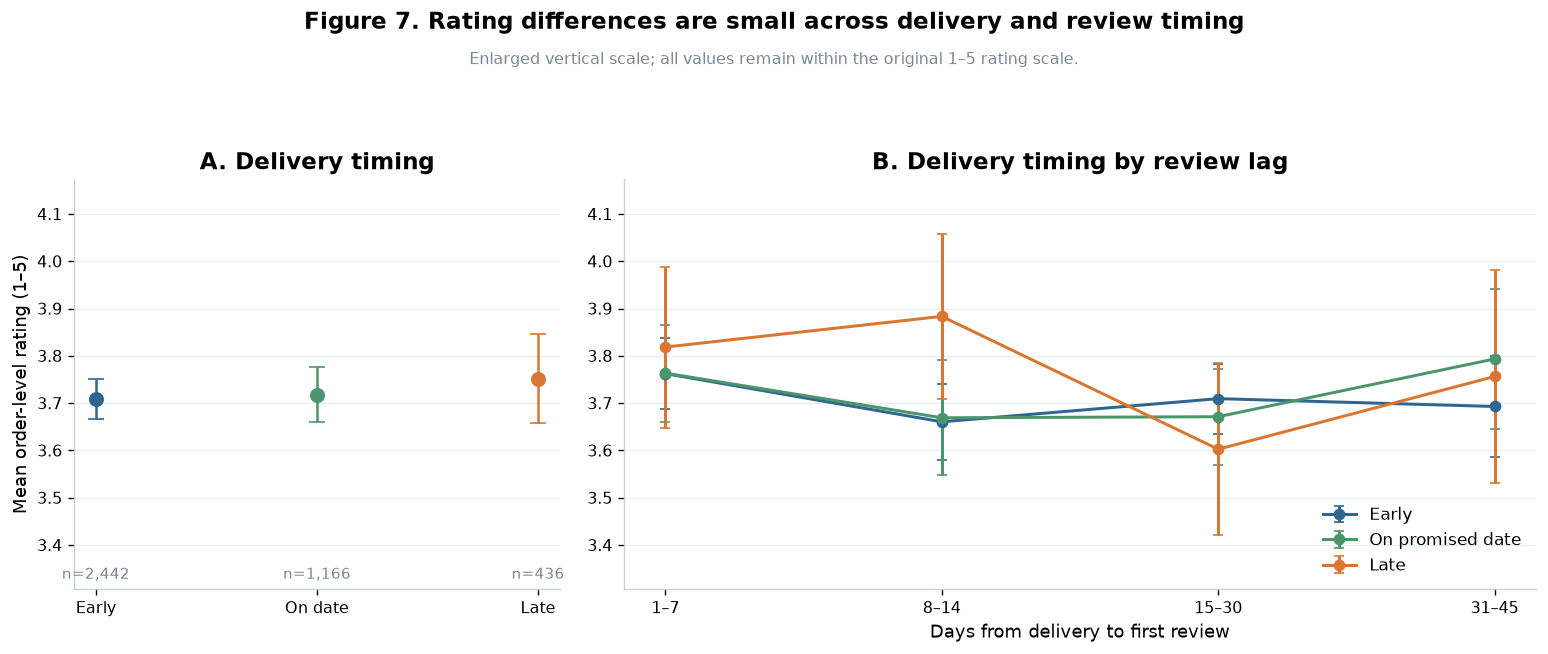

In [23]:
timing_colours = {'Early': BLUE, 'On promised date': GREEN, 'Late': ORANGE}
fig7, (ax_main, ax_lag) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [0.8, 1.5]})
rating_low = min((timing_rating['mean'] - timing_rating['ci95']).min(),
                 (lag_rating['mean'] - lag_rating['ci95']).min())
rating_high = max((timing_rating['mean'] + timing_rating['ci95']).max(),
                  (lag_rating['mean'] + lag_rating['ci95']).max())
rating_pad = max(0.08, (rating_high - rating_low) * 0.18)
zoom_limits = (max(1, rating_low - rating_pad), min(5, rating_high + rating_pad))

x_main = np.arange(len(timing_rating))
for idx, row in timing_rating.iterrows():
    ax_main.errorbar(idx, row['mean'], yerr=row.ci95, fmt='o', markersize=8, capsize=5,
                     color=timing_colours[row.delivery_timing])
    ax_main.text(idx, zoom_limits[0] + 0.015, f"n={int(row['count']):,}",
                 ha='center', va='bottom', fontsize=9, color=GREY)
ax_main.set_xticks(x_main, ['Early', 'On date', 'Late'])
ax_main.set_ylim(*zoom_limits)
ax_main.set_ylabel('Mean order-level rating (1–5)')
ax_main.set_title('A. Delivery timing')
ax_main.grid(axis='y', color=PALE, linewidth=0.8)

lag_order = ['1–7', '8–14', '15–30', '31–45']
x_lag = np.arange(len(lag_order))
for timing in timing_order:
    subset = lag_rating.loc[lag_rating.delivery_timing.eq(timing)].set_index('review_lag_band').reindex(lag_order)
    ax_lag.errorbar(x_lag, subset['mean'], yerr=subset['ci95'], marker='o', capsize=3,
                    linewidth=1.8, color=timing_colours[timing], label=timing)
ax_lag.set_xticks(x_lag, lag_order)
ax_lag.set_ylim(*zoom_limits)
ax_lag.set_xlabel('Days from delivery to first review')
ax_lag.set_title('B. Delivery timing by review lag')
ax_lag.grid(axis='y', color=PALE, linewidth=0.8)
ax_lag.legend(loc='lower right')

fig7.suptitle('Figure 7. Rating differences are small across delivery and review timing', y=1.04,
              fontsize=14, fontweight='bold')
fig7.text(0.5, 0.955, 'Enlarged vertical scale; all values remain within the original 1–5 rating scale.',
          ha='center', fontsize=9.5, color=GREY)
fig7.tight_layout(rect=[0, 0, 1, 0.91])
save_figure(fig7, 7)
plt.show()

Mean order-level ratings are **3.71 for early**, **3.72 for on-date** and **3.75 for late** deliveries. The confidence intervals overlap, and the review-lag panel has no stable monotonic pattern. This differs from the simple expectation that late delivery must produce a lower mean rating. Reviewer selection, product experience and the small late-delivery groups within each lag band could mask an association; this descriptive figure is not a causal test.

## 4. Coverage check before writing the report

At this stage we check that the figures collectively meet the assignment structure. The final ten numbered findings will be selected from these results, and the five ML questions will each cite the EDA evidence that motivates them.

In [24]:
figure_register = pd.DataFrame([
    (1, 'Order-value distribution', 'univariate distribution', 'orders', 'order', 'none'),
    (2, 'Discount and gross basket', 'bivariate group comparison', 'orders', 'order', 'none'),
    (3, 'Category contribution and rate', 'multivariate / product economics', 'order_items + products', 'order item', 'product_id many-to-one'),
    (4, 'Monthly frequency and value', 'temporal pattern', 'orders', 'month', 'none'),
    (5, 'Prior and current frequency', 'customer behaviour', 'orders + customers', 'customer', 'customer_id one-to-one after aggregation'),
    (6, 'OTIF and fulfilment by service', 'delivery operations / segmented', 'deliveries', 'delivery', 'relationship checked in solution'),
    (7, 'Delivery timing, review lag and rating', 'review behaviour + delivery operations', 'product_reviews + deliveries', 'rated order', 'order_id one-to-one after review aggregation'),
], columns=['figure', 'question_short', 'category', 'tables', 'analysis_unit', 'join'])
figure_register

,figure,question_short,category,tables,analysis_unit,join
0,1,Order-value distribution,univariate distribution,orders,order,none
1,2,Discount and gross basket,bivariate group comparison,orders,order,none
2,3,Category contribution and rate,multivariate / product economics,order_items + products,order item,product_id many-to-one
3,4,Monthly frequency and value,temporal pattern,orders,month,none
4,5,Prior and current frequency,customer behaviour,orders + customers,customer,customer_id one-to-one after aggregation
5,6,OTIF and fulfilment by service,delivery operations / segmented,deliveries,delivery,relationship checked in solution
6,7,"Delivery timing, review lag and rating",review behaviour + delivery operations,product_reviews + deliveries,rated order,order_id one-to-one after review aggregation


### Candidate links to the five ML questions

These are not model results. They record how a later ML question can be justified by an observed pattern rather than added as an unrelated idea.

In [25]:
ml_link_register = pd.DataFrame([
    ('OTIF-failure classification', 'Figure 6', 'carrier–service OTIF differs, with uncertainty'),
    ('Fulfilment-hours regression', 'Figure 6', 'fulfilment time has a broad overlapping distribution that may need order-level predictors'),
    ('Low-rating classification', 'Figure 7', 'simple delivery timing means do not separate low-rating risk'),
    ('Future customer-frequency regression', 'Figure 5', 'prior frequency alone has weak current-period association'),
    ('Product clustering', 'Figure 3', 'categories differ in contribution scale and estimated rate'),
], columns=['candidate_question', 'EDA_evidence', 'reason_for_next_step'])
ml_link_register

,candidate_question,EDA_evidence,reason_for_next_step
0,OTIF-failure classification,Figure 6,"carrier–service OTIF differs, with uncertainty"
1,Fulfilment-hours regression,Figure 6,fulfilment time has a broad overlapping distri...
2,Low-rating classification,Figure 7,simple delivery timing means do not separate l...
3,Future customer-frequency regression,Figure 5,prior frequency alone has weak current-period ...
4,Product clustering,Figure 3,categories differ in contribution scale and es...


## 5. Ten evidence-based findings

1. **Order value is concentrated in a long upper tail (Figure 1).** Across all 5,000 canonical orders, the median net total is **$2,555.44**, while the highest 10% begin at **$5,760.76**. The tail matters because a small group of orders accounts for unusually high transaction value. Product mix and quantity may explain these orders, so the threshold is suitable for investigation rather than automatic customer treatment.

2. **Deeper discounts are not accompanied by a clear increase in gross basket size (Figure 2).** Mean gross order value ranges from **$3,194.58 to $3,358.61** across the six discount groups, and their distributions overlap substantially. The 20% and 25% groups contain only 354 and 156 orders, so their confidence intervals are wider. Coupon allocation is observational; a controlled campaign would be needed before concluding that discount depth changes spending.

3. **Home Entertainment and Laptop provide the largest estimated margin pools (Figure 3).** At order-item grain, Home Entertainment contributes approximately **$1.040 million** and Laptop **$1.004 million** across 15,723 lines. This suggests that changes in these categories could have a large aggregate effect. The calculation uses catalogue cost and excludes allocated coupons, returns and overhead, so it is an operating indicator rather than accounting profit.

4. **The category with the highest estimated margin rate is not the largest contributor (Figure 3).** Networking has the highest estimated rate at **39.9%**, but its estimated contribution is about **$547,039**, roughly half that of Home Entertainment. Rate and scale therefore lead to different category priorities. Before changing assortment, realised discounts and category-specific operating costs should be included.

5. **Monthly order frequency and average value do not move together (Figure 4).** Daily order frequency ranges from **13.0 orders in February to 14.53 in April**, while mean order value ranges from **$2,884.01 in November to $3,115.23 in July**. Capacity and revenue planning should therefore treat transaction volume and basket value separately. One year of data and no campaign calendar are insufficient to identify a stable seasonal pattern.

6. **Prior order frequency is a weak stand-alone guide to current activity (Figure 5).** Across all 500 customers, prior-12-month orders and current-period orders have a Pearson correlation of only **0.08**. A retention rule based only on previous frequency would provide limited separation. Tenure, campaign exposure and product preference may account for changes, so these factors should be tested before using the relationship operationally.

7. **Most deliveries meet the OTIF definition, but the remaining failure share is still material (Figure 6).** Of 5,000 deliveries, **89.3%** are on time and in full, leaving approximately one in nine outside the target. This provides a clear operational outcome for further investigation. The aggregate rate hides differences in route difficulty, service mix and warehouse conditions, so interventions should not be assigned from the overall figure alone.

8. **Observed carrier–service OTIF rates differ, but several uncertainty intervals overlap (Figure 6).** DHL Express has the lowest observed rate at **87.0% (n=216)** and Direct Freight Express the highest at **92.1% (n=254)**. The overlap in Wilson intervals means the sample does not support a definitive league table. A fair comparison would adjust for distance, warehouse, order mix and repeated performance over time.

9. **Express service does not consistently produce shorter fulfilment inside the warehouse (Figure 6).** Median fulfilment ranges from **36.5 to 42.0 hours** across carrier–service groups, and the distributions overlap broadly. This suggests that dispatch preparation and external transport speed should be studied separately. Carrier selection may also be related to route and order characteristics, which are alternative explanations for the observed differences.

10. **Average rating shows no clear disadvantage for late delivery in this sample (Figure 7).** Among 4,044 rated orders, mean ratings are **3.71 for early (n=2,442)**, **3.72 for on-date (n=1,166)** and **3.75 for late delivery (n=436)**, with overlapping confidence intervals. This does not show that delays are harmless: only reviewed orders are observed, and product experience may dominate the average. Low-rating risk and delay severity deserve separate analysis.

## 6. Five future machine-learning questions

No model is trained in this assignment. Each question below starts from an EDA result and restricts predictors to information that would be available when the decision is made.

| No. | Question and business decision | Unit and target/objective | Decision-time predictors | Validation and metric | Main risk |
|---|---|---|---|---|---|
| **MLQ-1** | Can we identify orders at risk of OTIF failure early enough to prioritise intervention? Figure 6 shows a 10.7% overall failure share and uncertain carrier–service differences. | One order; binary target `on_time_in_full=False`. | Warehouse, order time, basket value and size, expedited flag, carrier, service level and shipping distance, using only fields known by dispatch. | Forward time split; PR-AUC, calibration and recall at the intervention capacity. | Delivered date, delay reason and completed tracking events would leak the outcome; compare errors across locations and service levels. |
| **MLQ-2** | Can fulfilment hours be predicted when warehouse work begins so staffing or escalation can be planned? Figure 6 shows broad and overlapping fulfilment distributions. | One delivery/order; regression target `fulfilment_hours`. | Order timestamp, warehouse, item count, total quantity, basket value, expedited flag, service level and distance available at fulfilment start. | Rolling temporal split; MAE and 90th-percentile absolute error. | Dispatch/delivery timestamps and later tracking events leak the target; monitor systematic underprediction by warehouse and service. |
| **MLQ-3** | Which completed orders are at risk of receiving a 1–2 star review so service recovery can be prioritised? Figure 7 shows that simple delivery timing means do not separate ratings well. | One completed order that is eligible for review; binary low-rating target after aggregating multiple reviews consistently. | Product/category mix, customer history and delivery facts available before outreach. | Time-based split by order completion; PR-AUC, recall at contact capacity and calibration. | Review text, helpful votes and realised rating fields leak the outcome; non-reviewers create selection bias and performance should be checked by language. |
| **MLQ-4** | Can the number of orders a customer will place in the next 90 days support retention planning? Figure 5 shows prior frequency alone has weak association. | One customer at a fixed prediction date; count target of orders in the following 90 days. | Orders strictly before the prediction date, recency/frequency/value summaries, tenure, tier, acquisition source and previous category mix. | Successive cohort-based temporal splits; MAE and Poisson deviance. | Future orders and retrospectively updated lifetime value leak the target; customer attributes may proxy sensitive characteristics. |
| **MLQ-5** | Can products be grouped into stable commercial roles for assortment review? Figure 3 shows that contribution and margin rate describe different category positions. | One product; unsupervised clusters based on lagged demand, revenue, estimated margin, price and review summaries. | Only measures calculated from a completed historical window, standardised before clustering. | Compare stability across adjacent time windows; silhouette score plus merchant interpretability. | Scale choices can dominate clusters, sparse products may be unstable, and catalogue cost does not represent full realised profitability. |

Together, the questions cover classification, regression and clustering. The temporal splits are important because a random split could allow later retail behaviour to make earlier cases look easier than they would be in use.

## 7. Limitations and conclusion

This analysis covers one retailer and one calendar year. It does not include campaign schedules, returns, realised operating costs, warehouse workload or route difficulty. Coupon, carrier and service assignments were not random, and product reviews represent customers who chose to leave feedback. The figures therefore describe associations in this export rather than causal effects. Estimated category margin should not be read as accounting profit, and the monthly analysis is too short to establish seasonality.

The strongest descriptive signals are the concentration of estimated category contribution and the remaining OTIF failure share. By contrast, discount depth does not clearly separate gross basket size, prior frequency is weak on its own, and average ratings differ little by delivery timing. These weak relationships are still useful because they show where simple rules would be unreliable. The next stage should use time-based evaluation, prevent outcome leakage and report uncertainty and subgroup performance before any operational use.

## References used for method choices

- NIST/SEMATECH. (n.d.). *Exploratory data analysis techniques*. NIST/SEMATECH e-Handbook of Statistical Methods. https://www.itl.nist.gov/div898/handbook/eda/section3/eda3.htm
- Ravula, P. (2023). Impact of delivery performance on online review ratings: The role of temporal distance of ratings. *Journal of Marketing Analytics, 11*(2), 149–158. https://doi.org/10.1057/s41270-022-00168-5
- Wikimedia Commons contributors. (2017). *Monash University logo* [SVG]. Wikimedia Commons. https://commons.wikimedia.org/wiki/File:Monash_University_logo.svg

The external study is used as motivation only. We do not reproduce its causal model or treat its reported effects as Group030 results.